## PyTorch workflow

![](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01_a_pytorch_workflow.png)

Let's explore an example PyTorch end-to-end workflow

| Topic | Contents | 
| ---- | ---- |
| **1. Getting data ready** | Data can be almost anything but to get started we're going to create a simple straight line |
| **2. Building a model** | Here we'll create a model to learn patterns in the date, we'll also chose a **loss function, optimizer** and build a **training loop**. |  
| **3. Fitting the model to data(training)** | We've got data a model, now let's let the model (try to) find patterns in the **(training)**  data. |
| **4. Making predictions and evaluating a model (inference)** | Our model's found patterns in the data, let's compare its findings to the acrual (**testing**) data. |
| **5. saving and loading model** | You may want to use your model elsewhere, or come back to it later, here we'll cover that. |
| **6. Putting it all together** | Let's take all of the above and combine it. |

In [1]:
What_were_Covering = {1: "Data (prepare and load)",
                      2: "Build model",
                      3: "Fitting the model to data(training)",
                      4: "making prediction and evaluting a model (inference)",
                      5: "saving and loading a model",
                      6: "putting it all together"}

What_were_Covering

{1: 'Data (prepare and load)',
 2: 'Build model',
 3: 'Fitting the model to data(training)',
 4: 'making prediction and evaluting a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn # nn contains all of PyTorch's building block for neural networks 
import matplotlib.pyplot as plt 

# Check PyTorch version
torch.__version__

'2.0.1'

# Data (prepare and load)

Data can be almost anythings... in Machine Learning

* Excel speadsheet
* Images of any kind
* Video (YouTube has lots of data....)
* Audio like songs or prodcats
* DNA 
* Text

Machine Learning is a game of two parts:
1. Get data into a numberical representation.
2. Build a model to learn patterns in that numerical representation

To showcase this, let's create some *known* data using the linear regression formula. 

We'll use a linear regression formula to make a straight line with known **parameters**

Y = a + bX


In [3]:
# Create *known* parameters

weight = 0.7 
bias = 0.3

#Create 
start = 0 
end = 1 
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general)

|No. |Split|Purpose|Amount Of Total Data| How often is it used?|
| ---- | ---- | ---- | ---- | ---- |
| 1. | Training Set | The model learns from this data (like the course materials you study during the semester). | ~60-80% | Always | 
| 2. | Validation Set | The model gets tuned on this data (like the practice exam you take before the final exam). |	~10-20%	| Often but not always |
| 3. | Test set | The model gets evaluated on this data to test what it has learned (like the final exam you take at the end of the semester). | ~10-20% |	Always


Let's Create a training and testing set with our data

In [5]:
# create a train/test split

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test =  X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(X_test)

(40, 40, 10, 10)

How might we better visualize our data?

This is where the data explore's motto comes in!

"Visualize, visualize, visualize!"

In [6]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

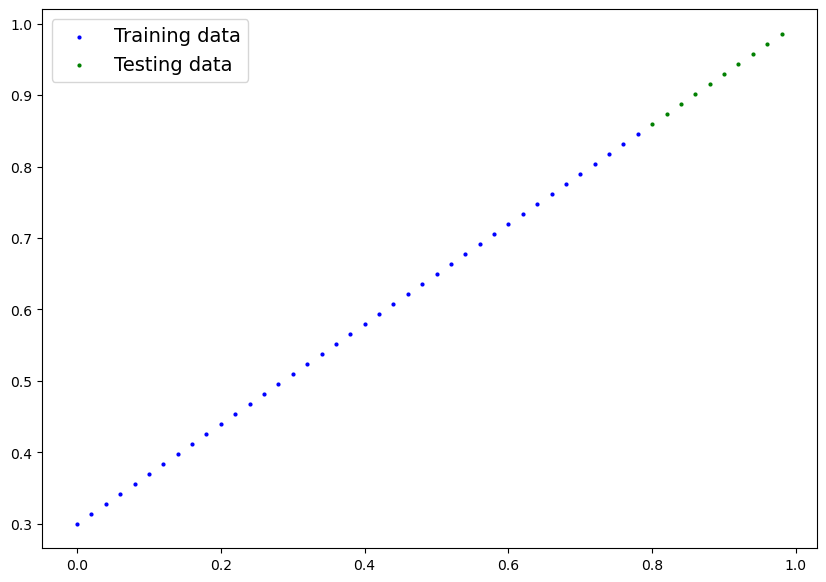

In [7]:
plot_predictions();

## 2. Build Model 

Our First PyTorch model

What our model does:
* Start with random values (weight & bias) 
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so? 
1. Gradient descent (Basic Idea about neural networks (https://www.youtube.com/watch?v=Ilg3gGewQ5U&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=3))
2. Backpropagation

![](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-linear-model-annotated.png)
Basic building blocks of creating a PyTorch model by subclassing `nn.Module`. For objects that subclass `nn.Module`, the `forward()` method must be defined.

In [8]:
# Create linear regression model class

class LinearRegressionModel(nn.Module):  # <- almost everythings in Pytorch inherhits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,                      # <- start with random weights (this will get adjusted as the model learns)
                                                requires_grad = True,   # <- can we update this value with gradient descent?)
                                                dtype = torch.float))   # <- PyTorch loves float32 by default
        
        self.bias = nn.Parameter(torch.randn(1,                         # <- start with random bias (this will get adjusted as the model learns)
                                                requires_grad = True,   # <- can we update this value with gradient descent?))
                                                dtype = torch.float))   # <- PyTorch loves float32 by default

    # Forward method to define the combination in the model 
    def forward(self, x:torch.Tensor) -> torch.Tensor: #<- "x" is the input data
        return self.weights * x + self.bias # this is the linear regression formula


### PyTorch model building essentials

* **torch.nn** - contains all of the building block for computational graphs (essentially a series of computations executed in a particular way) 
* **torch.nn.parameter** - what parameter shoud our model try and learn, often a Pytorch layer from torch.nn will set these for us
* **torch.module** - The base class for all neural network modules, if you subclass it, you should overwrite forward()
* **torch.nn** - this where the optimizers in PyTorch live, they will help with gradient descent
* **def forward()** - All nn.Module subclasses require a forward() method, this defines the computation that will take place on the data passed to the particular nn.Module (e.g. the linear regression formula above).

| PyTorch module | What Does it do? |
| ---- | ---- |
| [torch.nn](https://pytorch.org/docs/stable/nn.html) | Contains all of the building blocks for computational graphs (essentially a series of computations executed in a particular way). |
| [torch.nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) | The base class for all neural network modules, all the building blocks for neural networks are subclasses. If you're building a neural network in PyTorch, your models should subclass nn.Module. Requires a forward() method be implemented. | 
| [torch.optim](https://pytorch.org/docs/stable/optim.html) | Contains various optimization algorithms (these tell the model parameters stored in nn.Parameter how to best change to improve gradient descent and in turn reduce the loss). |
| [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) | Represent a map between key (label) and sample(features) pairs of yoyr data. Such as image and their associated labels. |
| [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html) | Creates a Python iterable over a torch Dataset(allows you to iterate over your data.) |

### Checking the contents of our PyTorch model

Now we have created a model, let's see what's inside....

So we can check our model parameters or what's inside our model using `.patameters()`.

In [9]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

#check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making  Prediction using `torch.inference_model()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`.

When we pass data through our model, it's going to run it through the `forward()` method.

In [11]:
y_pred = model_0(X_test)
y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [12]:
# Make predictions with model
with torch.inference_mode():  
    y_pred = model_0(X_test)

y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

### we can also do somethings similar with torch.no_grid(), however, torch.inference_mode() is preferred

In [13]:
with torch.no_grad():
    y_pred = model_0(X_test)

y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [14]:
y_pred, y_test

(tensor([[0.3982],
         [0.4049],
         [0.4116],
         [0.4184],
         [0.4251],
         [0.4318],
         [0.4386],
         [0.4453],
         [0.4520],
         [0.4588]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

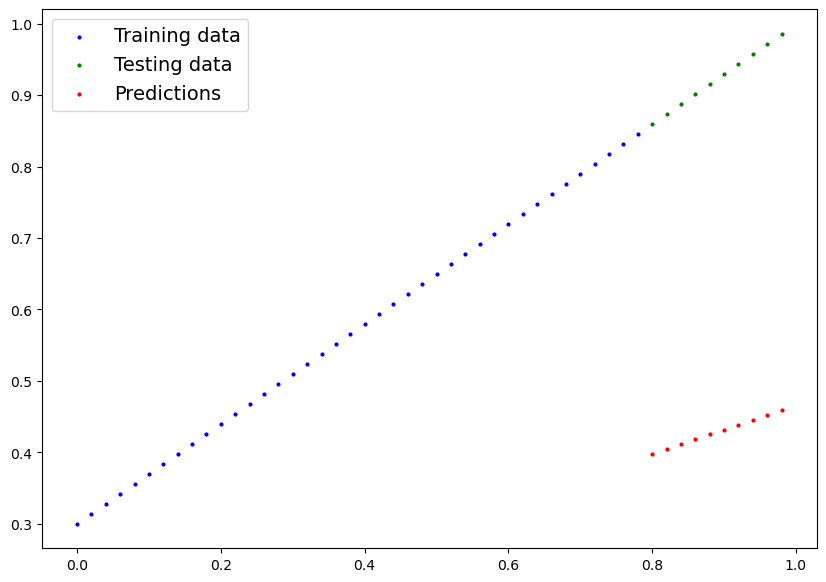

In [15]:
plot_predictions(predictions=y_pred)

## 3. Train model

The whole idea of training is for a model to move from some *unknown* parameters (these maybe random) to some *known* parameters.

Or in order words from a poor representation of the data to a better representation of the data. 

One way to measure how poor or how wrong models predictions are is to use a loss function.

* Note: Loss function may also be called cost function or criterion in different areas. For our case, we're going to refer to it as a loss function.

Things we need to train:

 * **Loss Function**: A function to Measures how wrong your models predictions are to the ideal outputs, lower is better. 
 * **Optimizer**: Takes into account the loss of a model and adjusts the model's parameters(e.g. weight & bias in our case) to improve the loss function
    * Inside the optimizer you'll often have to set two parameters: 
        * `params` - the model parameters you'd like to optimize, for example `params=model_0.parameters()
        * `lr`(learning rate) - The learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step (a small `lr` results in small changes,  a large `lr` results in large changes)

| Function | What does it do? | Where does it live in PyTorch? | Common Values |
| ---- | ---- | ---- | ---- |
| **Loss function** | Measures how wrong your models predictions (e.g.` y_preds`) are compared to the truth labels (e.g. `y_test`). Lower the better. | PyTorch has plenty of built-in loss functions in [torch.nn](https://pytorch.org/docs/stable/nn.html). | Mean absolute error (MAE) for regression problems ([torch.nn.L1Loss()](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html)). Binary cross entropy for binary classification problems ([torch.nn.BCELoss()](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)).|
| **Optimizer** | Tells your model how to update its internal parameters to best lower the loss. | You can find various optimization function implementations in [torch.optim](https://pytorch.org/docs/stable/optim.html). | Stochastic gradient descent ([torch.optim.SGD()](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD)). Adam optimizer ([torch.optim.Adam()](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam)). |


   

In [16]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [17]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [18]:
# Setup a loss function 
loss_fn = nn.L1Loss()

# Setup an Optimizer (SGD)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

**Q:** Which Loss function and Optimizer shold be used?

**A:**  This will be problem specific. But with experience, you'll get an idea of what works and what doesn't with your particular problem set. 

For example, for a regression problem (like ours), a loss function of `nn.L1Loss()` and an optimizer like `torch.optim.SGD()` will suffice.

But for a classification problem like classifying whether a photo is of a dog or cat, you'll likely want to use a loss function of `nn.BCELoss()`(Binary cross entropy loss)

### Building a training loop (and Testing loop) in PyTorch

A couple to thing we need in a training loop:
0. Loop through the data 
1. Forward pass (this involves data moving through data moving through our model's `forward()` function) to make predictions on data - also called forward propogation
2. calculate the loss (compare forward pass prredictions to ground trith labesl) 
3. Optimizer zero grad
4. Loss backward - move backwards through the network  to claculate the gradients of each of the parameters of our model with respect to the loss(**backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

In [20]:
torch.manual_seed(42)

# An epoch is one loop through the data....(This is a hyperprameter we've set it overselves)
epochs = 170

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []


## Training 

# 0. Loop through the data 
for epoch in range(epochs):
    #  set the model to traning mode
    model_0.train() #train mode in PyTorch set all parametersnthat required gradients

    # 1. Forward Pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss 
    loss = loss_fn(y_pred, y_train) # Training loss
    # print(f"Loss: {loss}")

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. perform backpropogation on the loss with respect to the parameters of the model
    loss.backward()

    # 5. Setup the optimizer (perform gradient descent)
    optimizer.step() # by default how the optimizer changes will calculate through the loop so... we have to zero them above in step 3 for the next iteration of the loop 

    # TESTING 
    # Turns off gradient tracking
    model_0.eval() # turn off different settings in the model not needed for evaluation/testing (drop/batch norm layers)
    with torch.inference_mode(): # turns off gradient tracking  & a couplr more things behind the scenes
     # 1. Forward pass 
     test_pred = model_0(X_test)

     # 2. Calaculate the loss
     test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:     
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().numpy())
        test_loss_values.append(test_loss.detach().numpy())
        print(f"Epoch: {epoch} | MAE TrainLoss: {loss} | MAE Test Loss: {test_loss}") 
        # print out model state_dict()
        # print(model_0.state_dict())

Epoch: 0 | MAE TrainLoss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495
Epoch: 10 | MAE TrainLoss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428
Epoch: 20 | MAE TrainLoss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688
Epoch: 30 | MAE TrainLoss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703
Epoch: 40 | MAE TrainLoss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106
Epoch: 50 | MAE TrainLoss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024
Epoch: 60 | MAE TrainLoss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135
Epoch: 70 | MAE TrainLoss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519
Epoch: 80 | MAE TrainLoss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484
Epoch: 90 | MAE TrainLoss: 0.02788740023970604 | MAE Test Loss: 0.06473556160926819
Epoch: 100 | MAE TrainLoss: 0.024458957836031914 | MAE Test Loss: 0.05646304413676262
Epoch: 110 | MAE TrainLoss: 0.021020209416747093 | MAE Test Loss: 0.048190496

### PyTorch Training loop
![](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-training-loop-annotated.png)

### PyTorch Testing loop 

![](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-testing-loop-annotated.png)

In [21]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

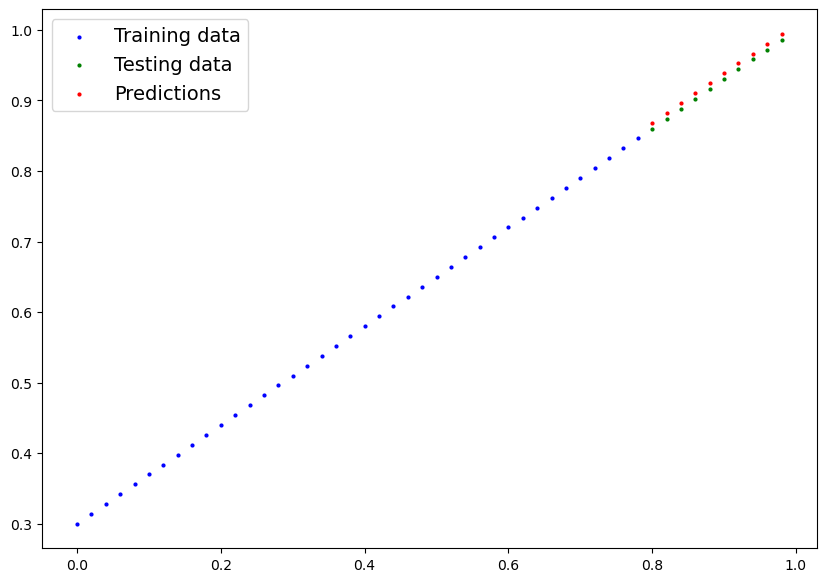

In [22]:
plot_predictions(predictions=y_preds_new)

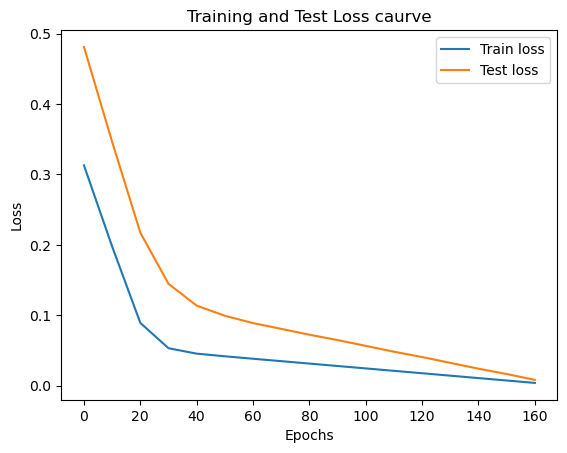

In [23]:
# Plot the loss curves

plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and Test Loss caurve")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [24]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


## 5. Saving and loading a PyTorch model

| PyTorch method | What does it do? |
| ---- | ---- |
| [torch.save](https://pytorch.org/docs/stable/generated/torch.save.html#torch.save) | Saves a serialized object to disk using Python's pickle utility. Models, tensors and various other Python objects like dictionaries can be saved using `torch.save`. |
| [torch.load](https://pytorch.org/docs/stable/generated/torch.load.html#torch.load) | Uses `pickle's` unpickling features to deserialize and load pickled Python object files (like models, tensors or dictionaries) into memory. You can also set which device to load the object to (CPU, GPU etc). |
| [torch.nn.Module.load.state_dict](https://pytorch.org/docs/stable/generated/torch.nn.Module.html?highlight=load_state_dict#torch.nn.Module.load_state_dict) | Loads a model's parameter dictionary (`model.state_dict()`) using a saved `state_dict()` object. |

In [30]:
## Google colab or cloud
from pathlib import Path 

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok = True)

# 2. Create model save path
MODEL_NAME = "01._pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save model satat dict
print(f"saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
            f = MODEL_SAVE_PATH)

saving model to: models/01._pytorch_workflow_model_0.pth


#### Loading a saved PyTorch model's state_dict()

Since we've now got a saved model `state_dict()` at `models/01_pytorch_workflow_model_0.pth` we can now load it in using `torch.nn.Module.load_state_dict(torch.load(f))` where `f` is the filepath of our saved model `state_dict()`.

In [36]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [37]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [39]:
# Make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test) 

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [40]:
loaded_model_preds == test_pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Putting it all together

We've covered a fair bit of ground so far.

But once you've had some practice, you'll be performing the above steps like dancing down the street.

Speaking of practice, let's put everything we've done so far together.

Except this time we'll make our code device agnostic (so if there's a GPU available, it'll use it and if not, it will default to the CPU).

There'll be far less commentary in this section than above since what we're going to go through has already been covered.

We'll start by importing the standard libraries we need.

In [41]:
# Import PyTorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

In [42]:
## For cuda
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [46]:
## for mac
# Is MPS even available? macOS 12.3+
print(torch.backends.mps.is_available())

# was the current version pf PyTorch built with MPS activated?
print(torch.backends.mps.is_built())

True
True


### 6.1 Data 

In [44]:
# Create weight and bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) # without unsqueeze, errors will happen later on (shapes within linear layers)
y = weight * X + bias 
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

Now we've got some data, let's split into training  and test sets.

we'll use an 80/20 split with 80% training data and 20% testing data.

In [51]:
# split data 
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

let's visualize them to make sure they look okay.

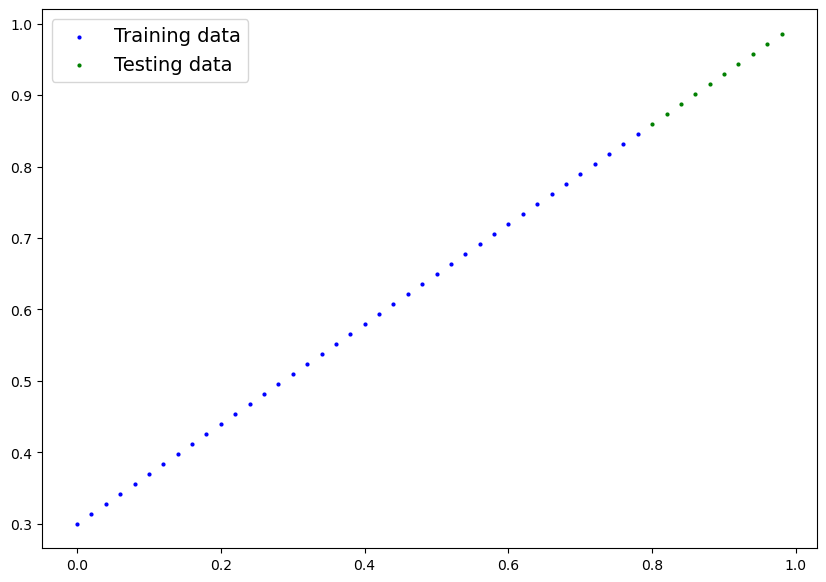

In [52]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

### 6.2 Building a PyTorch linear model

We've got some data, now it's time to make a model.

We'll create the same style of model as before except this time, instead of defining the weight and bias parameters of our model manually using `nn.Parameter()`, we'll use `nn.Linear(in_features, out_features)` to do it for us.

Where `in_features` is the number of dimensions your input data has and `out_features` is the number of dimensions you'd like it to be output to.

In our case, both of these are `1` since our data has `1` input feature (`X`) per label (`y`).

![Linear regression model with nn.Parameter](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-linear-regression-model-with-nn-Parameter-and-nn-Linear-compared.png)


In [70]:
## Subclass nn.Module to make our model

class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features = 1,    
                                      out_features = 1)
    
    # Define the forward computation (input data x flows through nn.Linear())
    def forward(self, x : torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)


# Set the manual seed when creating the model (this isn't always need but is used for demonstrative purposes, try commenting it out and seeing what happens)
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

Notice the outputs of `model_1.state_dict()`, the `nn.Linear()` layer created a random `weight` and `bias` parameter for us.

Now let's put our model on the GPU (if it's available).

We can change the device our PyTorch objects are on using `.to(device)`.

First let's check the model's current device.

In [71]:
# Check model device
next(model_1.parameters()).device

device(type='cpu')

Let's change it to be on the GPU (if it's available).

In [72]:
# Set model to GPU if it's availalble, otherwise it'll default to CPU
model_1.to(device) # the device variable was set above to be "cuda" if available or "cpu" if not
next(model_1.parameters()).device

device(type='mps', index=0)

In [73]:
import torch
torch.has_mps

True

In [74]:
## For mac 
device = torch.device('mps')
model_1.to(device)
next(model_1.parameters()).device
device

device(type='mps')

### 6.3 Training 

Time to build a training and testing loop.

First we'll need a loss function and an optimizer.

Let's use the same functions we used earlier, `nn.L1Loss()` and `torch.optim.SGD()`.

We'll have to pass the new model's parameters (`model.parameters()`) to the optimizer for it to adjust them during training.

The learning rate of `0.01` worked well before too so let's use that again.

In [75]:
## Create loss function
loss_fn = nn.L1Loss()


## Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),    # optimize newly created model's parameters
                            lr = 0.01)

Beautiful, loss function and optimizer ready, now let's train and evaluate our model using a training and testing loop.

The only different thing we'll be doing in this step compared to the previous training loop is putting the data on the target `device`.

We've already put our model on the target `device` using `model_1.to(device)`.

And we can do the same with the data.

That way if the model is on the GPU, the data is on the GPU (and vice versa).

Let's step things up a notch this time and set `epochs=200`.

If you need a reminder of the PyTorch training loop steps, see below.

### PyTorch training loop setps

1. **Forward pass** - The model goes through all of the training data once, performing its `forward()` function calculations (`model(x_train)`).

2. **Calculate the loss** - The model's outputs (predictions) are compared to the ground truth and evaluated to see how wrong they are (`loss = loss_fn(y_pred, y_train)`).

3. **Zero gradients** - The optimizers gradients are set to zero (they are accumulated by default) so they can be recalculated for the specific training step (`optimizer.zero_grad()`).

4. **Perform backpropagation on the loss** - Computes the gradient of the loss with respect for every model parameter to be updated (each parameter with `requires_grad=True`). This is known as **backpropagation**, hence "backwards" (`loss.backward()`).

4. **Step the optimizer (gradient descent)** - Update the parameters with `requires_grad=True` with respect to the loss gradients in order to improve them (`optimizer.step()`).

In [79]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 200

# Put data on the available device
# Without this, error will happen (not all model/data on device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)


for epoch in range(epochs):

    ## Training
    model_1.train() # train mode is on by default after construction

    # 1. Forward pass 
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Perform backpropogation
    loss.backward()

    # 5. Step the optimizer 
    optimizer.step()

    ## Testing
    model_1.eval()  # put the model in evaluation mode for testing (inference)

    # 1. Forward pass 
    with torch.inference_mode():
        test_pred = model_1(X_test)

        # 2. Calculate the loss 
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")


/Users/dhavalantala/Desktop/pytorch/venv/lib/python3.9/site-packages/torch/autograd/__init__.py:200: UserWarning: The operator 'aten::sgn.out' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1682343673238/work/aten/src/ATen/mps/MPSFallback.mm:11.)
  Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch: 0 | Train loss: 0.5551779270172119 | Test loss: 0.5739762783050537
Epoch: 10 | Train loss: 0.4399681091308594 | Test loss: 0.4392664134502411
Epoch: 20 | Train loss: 0.3247582018375397 | Test loss: 0.30455657839775085
Epoch: 30 | Train loss: 0.20954833924770355 | Test loss: 0.16984672844409943
Epoch: 40 | Train loss: 0.09433844685554504 | Test loss: 0.03513689711689949
Epoch: 50 | Train loss: 0.023886388167738914 | Test loss: 0.04784906655550003
Epoch: 60 | Train loss: 0.0199567973613739 | Test loss: 0.04580312594771385
Epoch: 70 | Train loss: 0.016517987474799156 | Test loss: 0.0375305712223053
Epoch: 80 | Train loss: 0.01308917161077261 | Test loss: 0.029944902285933495
Epoch: 90 | Train loss: 0.009653176181018353 | Test loss: 0.02167237363755703
Epoch: 100 | Train loss: 0.0062156799249351025 | Test loss: 0.014086711220443249
Epoch: 110 | Train loss: 0.00278724217787385 | Test loss: 0.005814164876937866
Epoch: 120 | Train loss: 0.0012645028764382005 | Test loss: 0.013801807537

Let's check the parameters our model has learned and compare them to the original parameters we hard-coded.



In [80]:
# Find our model's learned parameters
from pprint import pprint # pprint = pretty print, see: https://docs.python.org/3/library/pprint.html 
print("The model learned the following values for weights and bias:")
pprint(model_1.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='mps:0')),
             ('linear_layer.bias', tensor([0.3025], device='mps:0'))])

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


### 6.4 Making and evaluating predictions

In [81]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_pred = model_1(X_test)
y_pred

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='mps:0')

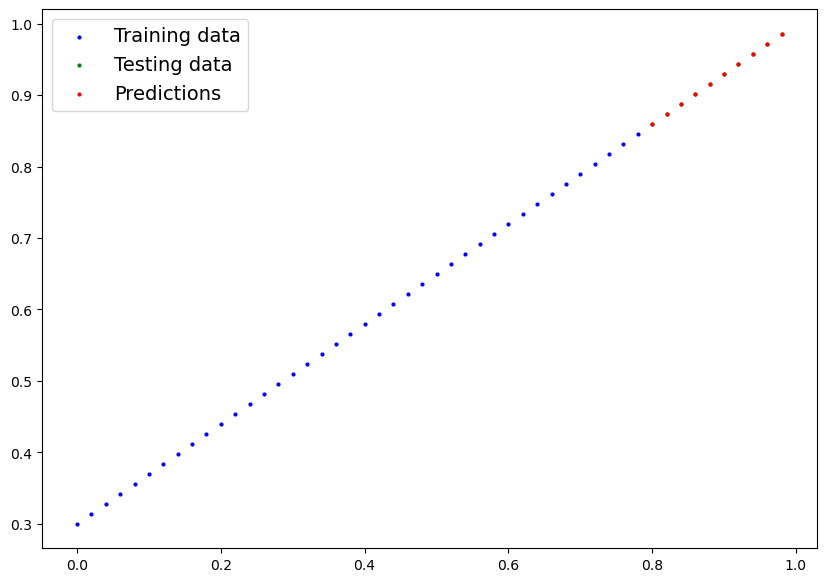

In [83]:
# Check out our model predictions visually 
plot_predictions(predictions=y_pred.cpu())

### 6.5 Saving and loading a model

we're happy with out models predictons, so ley's save it to file so it can be used later.

In [84]:
from pathlib import Path

# 1. Create models directory 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path 
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH) 

Saving model to: models/01_pytorch_workflow_model_1.pth


And just to make sure everything worked well, let's load it back in.

We'll:

* Create a new instance of the `LinearRegressionModelV2()` class
* Load in the model state dict using `torch.nn.Module.load_state_dict()`
* Send the new instance of the model to the target device (to ensure our code is device-agnostic)

In [85]:
# Instantiate a fresh instance of LinearRegressionModelV2
loaded_model_1 = LinearRegressionModelV2()

# Load model state dict 
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put model to target device (if your data is on GPU, model will have to be on GPU to make predictions)
loaded_model_1.to(device)

print(f"Loaded model:\n{loaded_model_1}")
print(f"Model on device:\n{next(loaded_model_1.parameters()).device}")

Loaded model:
LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
Model on device:
mps:0



Now we can evaluate the loaded model to see if its predictions line up with the predictions made prior to saving.

In [87]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_pred == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='mps:0')

## Exercises